# Обучение baseline-моделей

Пробую несколько классических алгоритмов и смотрю кто лучше справляется с сильным дисбалансом классов.

**Данные:** Credit Card Fraud Detection (Kaggle, ULB). 284 807 транзакций, признаки Time, Amount, V1–V28. Сплит 60/20/20, stratified, random_state=42.

**Модели:** Logistic Regression, Random Forest, LightGBM, XGBoost  
**Главная метрика:** PR-AUC — при таком дисбалансе (0.17% мошенничеств) ROC-AUC не очень информативен

**Выводы:** LightGBM показал лучший результат — PR-AUC=0.8359, F1=0.8432 на val. Оптимальный порог классификации ~0.11 (не стандартные 0.5). Logistic Regression значительно слабее остальных.

In [1]:
import sys
sys.path.append('..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import mlflow
import mlflow.sklearn
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    average_precision_score, roc_auc_score, f1_score,
    precision_recall_curve, confusion_matrix, classification_report
)
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier

from src.data.pipeline import load_data, split_data, fit_preprocessor, apply_preprocessor, get_X_y

plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

MLFLOW_EXPERIMENT = 'fraud_detection_baseline'
mlflow.set_experiment(MLFLOW_EXPERIMENT)
print('MLflow experiment:', MLFLOW_EXPERIMENT)

2026/05/22 11:25:29 INFO mlflow.tracking.fluent: Experiment with name 'fraud_detection_baseline' does not exist. Creating a new experiment.


MLflow experiment: fraud_detection_baseline


## Загрузка данных

In [2]:
df = load_data('../data/creditcard.csv')
train, val, test = split_data(df)

# Препроцессор обучаем ТОЛЬКО на train
preprocessor = fit_preprocessor(train, save_path='../models/preprocessor.pkl')

X_train = apply_preprocessor(preprocessor, train)
X_val   = apply_preprocessor(preprocessor, val)
X_test  = apply_preprocessor(preprocessor, test)

_, y_train = get_X_y(train)
_, y_val   = get_X_y(val)
_, y_test  = get_X_y(test)

print(f'\nX_train: {X_train.shape}, fraud: {y_train.sum()}')
print(f'X_val:   {X_val.shape}, fraud: {y_val.sum()}')
print(f'X_test:  {X_test.shape}, fraud: {y_test.sum()}')

Train: 170,883  |  fraud: 295 (0.173%)
Val:   56,962  |  fraud: 99 (0.174%)
Test:  56,962  |  fraud: 98 (0.172%)
Препроцессор сохранён: ../models/preprocessor.pkl

X_train: (170883, 30), fraud: 295
X_val:   (56962, 30), fraud: 99
X_test:  (56962, 30), fraud: 98


## Вспомогательные функции

In [3]:
def precision_at_recall(y_true, y_scores, min_recall=0.80):
    """Максимальная Precision при Recall >= min_recall."""
    precision, recall, _ = precision_recall_curve(y_true, y_scores)
    mask = recall >= min_recall
    if not mask.any():
        return 0.0
    return float(precision[mask].max())


def evaluate(model, X, y, threshold=0.5):
    """Считает все метрики для модели."""
    scores = model.predict_proba(X)[:, 1]
    preds  = (scores >= threshold).astype(int)
    return {
        'pr_auc':   round(average_precision_score(y, scores), 4),
        'roc_auc':  round(roc_auc_score(y, scores), 4),
        'f1':       round(f1_score(y, preds), 4),
        'p_at_r80': round(precision_at_recall(y, scores, 0.80), 4),
    }


def train_and_log(name, model, params, X_tr, y_tr, X_v, y_v):
    """Обучает модель и логирует всё в MLflow."""
    with mlflow.start_run(run_name=name):
        mlflow.log_params(params)
        model.fit(X_tr, y_tr)
        metrics = evaluate(model, X_v, y_v)
        mlflow.log_metrics(metrics)
        mlflow.sklearn.log_model(model, 'model')

    print(f'{name:20s} | PR-AUC={metrics["pr_auc"]:.4f} | ROC-AUC={metrics["roc_auc"]:.4f} '
          f'| F1={metrics["f1"]:.4f} | P@R80={metrics["p_at_r80"]:.4f}')
    return model, metrics


results = {}  # name -> metrics
models  = {}  # name -> fitted model

## Logistic Regression

Простейший baseline — посмотрим от чего отталкиваться.

In [4]:
params_lr = {'C': 0.1, 'max_iter': 1000, 'class_weight': 'balanced', 'solver': 'lbfgs'}
lr = LogisticRegression(**params_lr, random_state=42)
models['LogReg'], results['LogReg'] = train_and_log('LogReg', lr, params_lr, X_train, y_train, X_val, y_val)

2026/05/22 11:25:34 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LogReg               | PR-AUC=0.6734 | ROC-AUC=0.9748 | F1=0.1112 | P@R80=0.5128


## Random Forest

In [5]:
params_rf = {'n_estimators': 200, 'max_depth': 12, 'class_weight': 'balanced', 'n_jobs': -1}
rf = RandomForestClassifier(**params_rf, random_state=42)
models['RandomForest'], results['RandomForest'] = train_and_log('RandomForest', rf, params_rf, X_train, y_train, X_val, y_val)

2026/05/22 11:25:53 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


RandomForest         | PR-AUC=0.7798 | ROC-AUC=0.9691 | F1=0.8022 | P@R80=0.6723


## LightGBM

In [6]:
params_lgbm = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'num_leaves': 31, 'class_weight': 'balanced',
    'n_jobs': -1, 'verbose': -1,
}
lgbm = LGBMClassifier(**params_lgbm, random_state=42)
models['LightGBM'], results['LightGBM'] = train_and_log('LightGBM', lgbm, params_lgbm, X_train, y_train, X_val, y_val)

2026/05/22 11:25:59 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


LightGBM             | PR-AUC=0.8359 | ROC-AUC=0.9732 | F1=0.8432 | P@R80=0.8791


## XGBoost

In [7]:
scale_pos = int((y_train == 0).sum() / (y_train == 1).sum())
params_xgb = {
    'n_estimators': 500, 'learning_rate': 0.05,
    'max_depth': 6, 'scale_pos_weight': scale_pos,
    'n_jobs': -1, 'eval_metric': 'aucpr',
}
xgb = XGBClassifier(**params_xgb, random_state=42)
models['XGBoost'], results['XGBoost'] = train_and_log('XGBoost', xgb, params_xgb, X_train, y_train, X_val, y_val)

2026/05/22 11:26:03 WARNING mlflow.models.model: Model logged without a signature and input example. Please set `input_example` parameter when logging the model to auto infer the model signature.


XGBoost              | PR-AUC=0.8257 | ROC-AUC=0.9722 | F1=0.8324 | P@R80=0.6957


## Сравнение результатов

In [8]:
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('pr_auc', ascending=False)
print('=== Сравнение моделей на val-выборке ===')
print(results_df.to_string())

=== Сравнение моделей на val-выборке ===
              pr_auc  roc_auc      f1  p_at_r80
LightGBM      0.8359   0.9732  0.8432    0.8791
XGBoost       0.8257   0.9722  0.8324    0.6957
RandomForest  0.7798   0.9691  0.8022    0.6723
LogReg        0.6734   0.9748  0.1112    0.5128


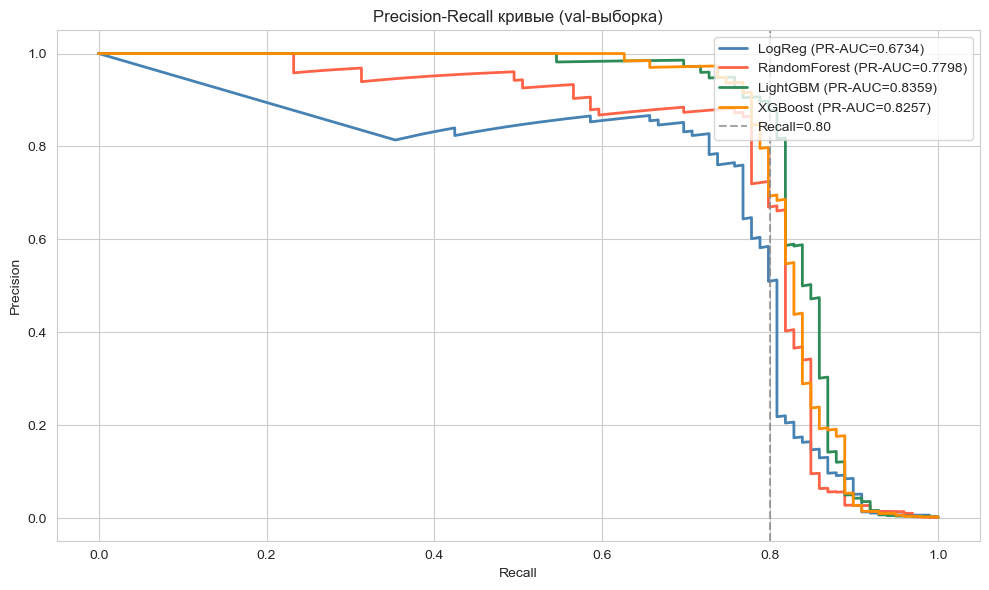

In [9]:
# Precision-Recall кривые всех моделей
plt.figure(figsize=(10, 6))
colors = ['steelblue', 'tomato', 'seagreen', 'darkorange']

for (name, model), color in zip(models.items(), colors):
    scores = model.predict_proba(X_val)[:, 1]
    prec, rec, _ = precision_recall_curve(y_val, scores)
    auc = average_precision_score(y_val, scores)
    plt.plot(rec, prec, color=color, lw=2, label=f'{name} (PR-AUC={auc:.4f})')

plt.axvline(x=0.80, color='gray', linestyle='--', alpha=0.7, label='Recall=0.80')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall кривые (val-выборка)')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('../artifacts/pr_curves_baseline.png', dpi=100, bbox_inches='tight')
plt.show()

## Разбор ошибок лучшей модели

LightGBM победил — смотрю где именно он ошибается.

In [10]:
best_name = results_df.index[0]
best_model = models[best_name]
print(f'Лучшая модель: {best_name}')

# Выбираем порог по PR-кривой: максимальный F1 на val
scores_val = best_model.predict_proba(X_val)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_val, scores_val)
f1_scores = 2 * precision * recall / (precision + recall + 1e-9)
best_idx = f1_scores.argmax()
best_threshold = float(thresholds[best_idx])

print(f'Оптимальный порог (max F1 на val): {best_threshold:.4f}')
print(f'F1 при этом пороге: {f1_scores[best_idx]:.4f}')

Лучшая модель: LightGBM
Оптимальный порог (max F1 на val): 0.1095
F1 при этом пороге: 0.8449


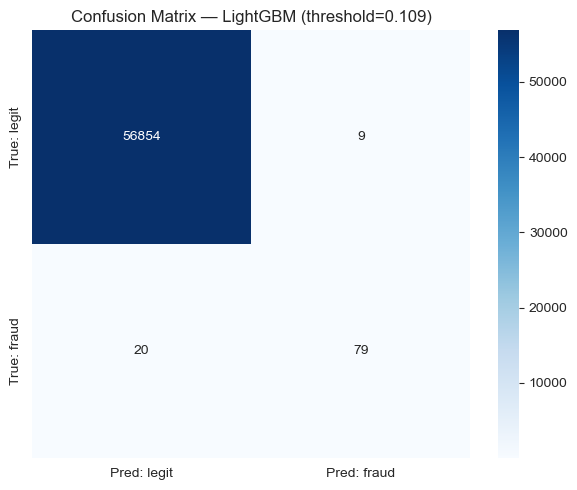

              precision    recall  f1-score   support

       legit       1.00      1.00      1.00     56863
       fraud       0.90      0.80      0.84        99

    accuracy                           1.00     56962
   macro avg       0.95      0.90      0.92     56962
weighted avg       1.00      1.00      1.00     56962



In [11]:
preds_val = (scores_val >= best_threshold).astype(int)
cm = confusion_matrix(y_val, preds_val)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: legit', 'Pred: fraud'],
            yticklabels=['True: legit', 'True: fraud'])
plt.title(f'Confusion Matrix — {best_name} (threshold={best_threshold:.3f})')
plt.tight_layout()
plt.savefig('../artifacts/confusion_matrix_best.png', dpi=100, bbox_inches='tight')
plt.show()

print(classification_report(y_val, preds_val, target_names=['legit', 'fraud']))

## Итог

LightGBM с PR-AUC = 0.8359 идёт дальше в следующий ноутбук.

In [12]:
print('=' * 55)
print('ИТОГИ СЕССИИ 2 — Baseline модели')
print('=' * 55)
print(results_df.to_string())
print()
print(f'Лучшая модель: {best_name}')
print(f'PR-AUC: {results[best_name]["pr_auc"]}')
print(f'Оптимальный порог: {best_threshold:.4f}')
print()
print('Следующий шаг: Сессия 3 — нейросеть MLP + финальный выбор модели')

ИТОГИ СЕССИИ 2 — Baseline модели
              pr_auc  roc_auc      f1  p_at_r80
LightGBM      0.8359   0.9732  0.8432    0.8791
XGBoost       0.8257   0.9722  0.8324    0.6957
RandomForest  0.7798   0.9691  0.8022    0.6723
LogReg        0.6734   0.9748  0.1112    0.5128

Лучшая модель: LightGBM
PR-AUC: 0.8359
Оптимальный порог: 0.1095

Следующий шаг: Сессия 3 — нейросеть MLP + финальный выбор модели
